## Read in the Indian Liver Patient Data

In [1]:
import pandas as pd

df = pd.read_csv('../data/indian_liver_patient.csv')

df.head()

,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Dataset
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,1
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,1
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,1


In [2]:
df.tail()

,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Dataset
578,60,Male,0.5,0.1,500,20,34,5.9,1.6,0.37,2
579,40,Male,0.6,0.1,98,35,31,6.0,3.2,1.10,1
580,52,Male,0.8,0.2,245,48,49,6.4,3.2,1.00,1
581,31,Male,1.3,0.5,184,29,32,6.8,3.4,1.00,1
582,38,Male,1.0,0.3,216,21,24,7.3,4.4,1.50,2


## Display the structure of the data

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 583 entries, 0 to 582
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         583 non-null    int64  
 1   Gender                      583 non-null    str    
 2   Total_Bilirubin             583 non-null    float64
 3   Direct_Bilirubin            583 non-null    float64
 4   Alkaline_Phosphotase        583 non-null    int64  
 5   Alamine_Aminotransferase    583 non-null    int64  
 6   Aspartate_Aminotransferase  583 non-null    int64  
 7   Total_Protiens              583 non-null    float64
 8   Albumin                     583 non-null    float64
 9   Albumin_and_Globulin_Ratio  579 non-null    float64
 10  Dataset                     583 non-null    int64  
dtypes: float64(5), int64(5), str(1)
memory usage: 50.2 KB


In [4]:
df.count()

Age                           583
Gender                        583
Total_Bilirubin               583
Direct_Bilirubin              583
Alkaline_Phosphotase          583
Alamine_Aminotransferase      583
Aspartate_Aminotransferase    583
Total_Protiens                583
Albumin                       583
Albumin_and_Globulin_Ratio    579
Dataset                       583
dtype: int64

## Handle missing values

In [ ]:
df.isnull().sum()
# Looking through the data set to see the total amount of NaN values
# Albumin_and_Globulin_Ratio has 4 NaN values

Age                           0
Gender                        0
Total_Bilirubin               0
Direct_Bilirubin              0
Alkaline_Phosphotase          0
Alamine_Aminotransferase      0
Aspartate_Aminotransferase    0
Total_Protiens                0
Albumin                       0
Albumin_and_Globulin_Ratio    0
Dataset                       0
dtype: int64

In [6]:
df = df.dropna()

df.isnull().sum()

Age                           0
Gender                        0
Total_Bilirubin               0
Direct_Bilirubin              0
Alkaline_Phosphotase          0
Alamine_Aminotransferase      0
Aspartate_Aminotransferase    0
Total_Protiens                0
Albumin                       0
Albumin_and_Globulin_Ratio    0
Dataset                       0
dtype: int64

## Encode catergorical data (change to numerical variables)

In [7]:
df.info()

# Most of the data are numerical values except Gender

<class 'pandas.DataFrame'>
Index: 579 entries, 0 to 582
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         579 non-null    int64  
 1   Gender                      579 non-null    str    
 2   Total_Bilirubin             579 non-null    float64
 3   Direct_Bilirubin            579 non-null    float64
 4   Alkaline_Phosphotase        579 non-null    int64  
 5   Alamine_Aminotransferase    579 non-null    int64  
 6   Aspartate_Aminotransferase  579 non-null    int64  
 7   Total_Protiens              579 non-null    float64
 8   Albumin                     579 non-null    float64
 9   Albumin_and_Globulin_Ratio  579 non-null    float64
 10  Dataset                     579 non-null    int64  
dtypes: float64(5), int64(5), str(1)
memory usage: 54.3 KB


In [ ]:
df['Gender'] = df['Gender'].replace(['Male', 'Female'], [1, 0])

df.head()

,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Dataset
0,65,0,0.7,0.1,187,16,18,6.8,3.3,0.90,1
1,62,1,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,1,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,58,1,1.0,0.4,182,14,20,6.8,3.4,1.00,1
4,72,1,3.9,2.0,195,27,59,7.3,2.4,0.40,1


## Split data into training (80%) and testing (20%) sets

In [ ]:
df['Dataset'].value_counts()

# For training and testing, binary labels are required

Dataset
1    414
2    165
Name: count, dtype: int64

In [14]:
df['Dataset'] = df['Dataset'].replace(2, 0)

df['Dataset'].value_counts()

Dataset
1    414
0    165
Name: count, dtype: int64

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, recall_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# A list of the features we are going to use
feature = ['Age', 'Gender', 'Total_Bilirubin', 'Direct_Bilirubin', 'Alkaline_Phosphotase', 'Alamine_Aminotransferase', 'Aspartate_Aminotransferase', 'Total_Protiens', 'Albumin', 'Albumin_and_Globulin_Ratio']
target = 'Dataset'

# Define our `X` and `y`, and split it into train/test
X = df[feature]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print('Lenght of our Training data:', X_train.shape, '\nLength of our Testing data:', y_train.shape)

Lenght of our Training data: (463, 10) 
Length of our Testing data: (463,)


## Train Decision Tree Classifier

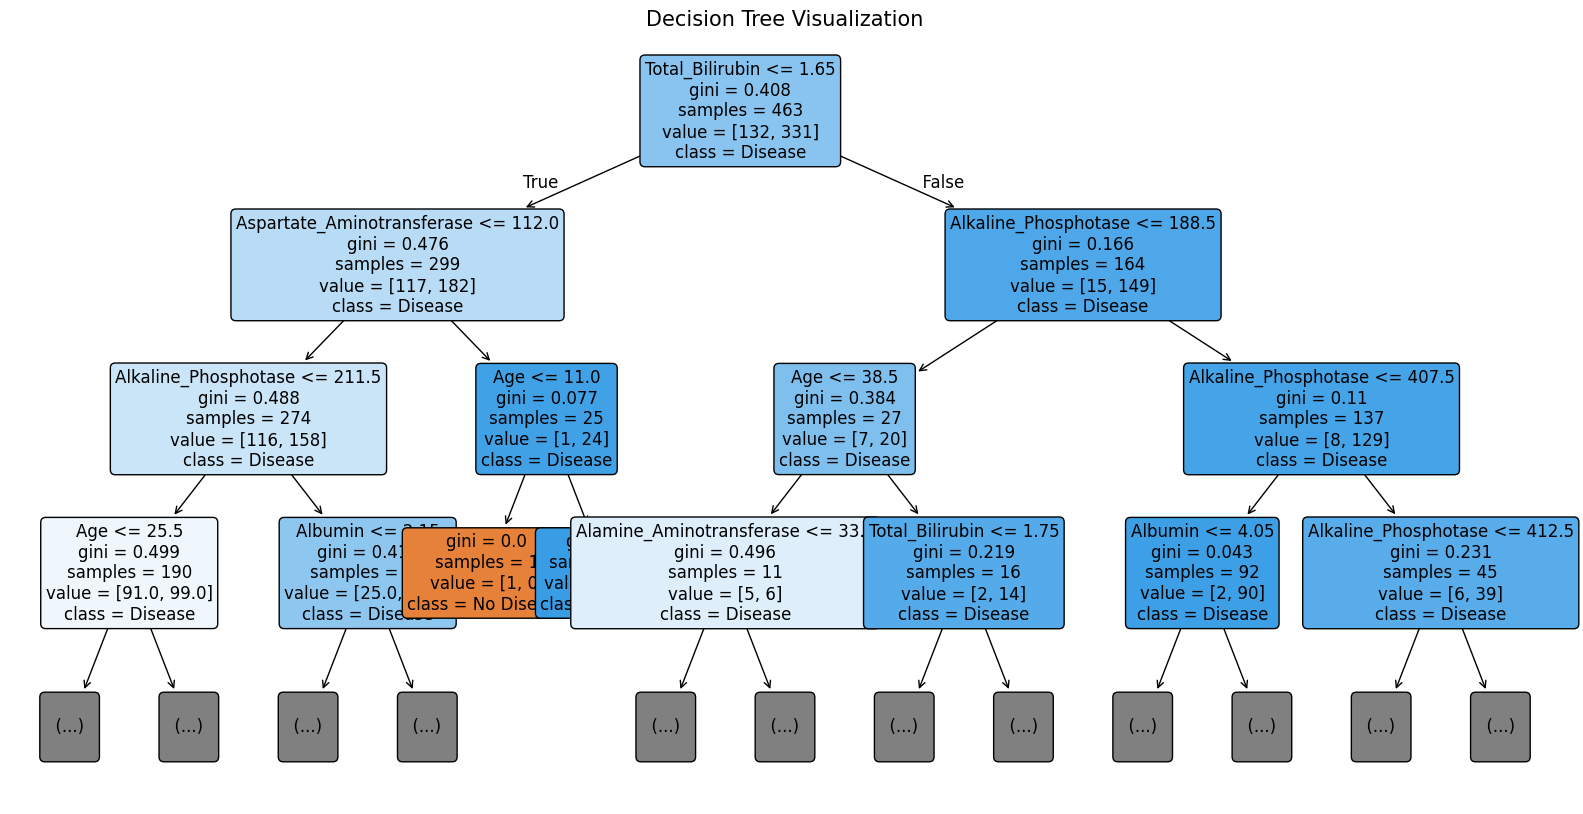

In [28]:
# For our first pass, initialize our model
model = DecisionTreeClassifier(max_depth=4)

# Fit our model with our training data
model.fit(X_train, y_train)

# Make predictions of our testing data
y_pred = model.predict(X_test)

# Create a large figure so the tree isn't cramped
plt.figure(figsize=(20, 10))

# Plot the tree
plot_tree(model, 
          feature_names=feature, 
          class_names=['No Disease', 'Disease'], 
          filled=True, 
          rounded=True, 
          fontsize=12,
          max_depth=3) 

plt.title("Decision Tree Visualization", fontsize=15)
plt.show()

Accuracy: 0.71
Sensitivity: 0.95
Specificity: 0.09


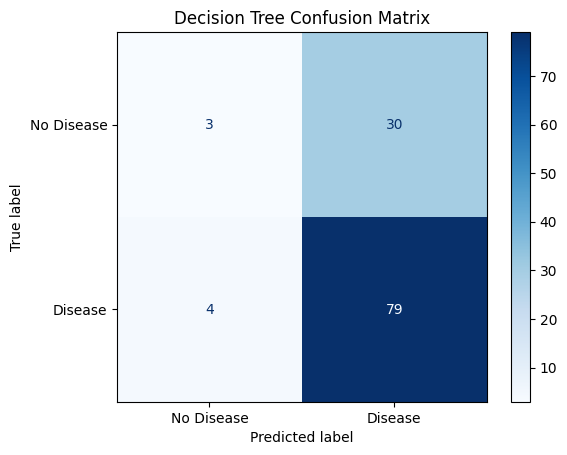

In [29]:
# Evaluate and print our model scores using accuracy, recall and confusion matrix
accuracy = accuracy_score(y_true=y_test, y_pred=y_pred)
print(f"Accuracy: {accuracy:.2f}")

sensitivity = recall_score(y_true=y_test, y_pred=y_pred)
print(f"Sensitivity: {sensitivity:.2f}")

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
specificity = tn / (tn + fp)

print(f"Specificity: {specificity:.2f}")

# Create the visual plot
ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, display_labels=['No Disease', 'Disease'], cmap='Blues')
plt.title("Decision Tree Confusion Matrix")
plt.show()

## Random Forest - Map-Reduce Ensemble

In [30]:
from sklearn.ensemble import RandomForestClassifier

depths = [3, 5, 7]

for d in depths:
    # 1. Initialize and Train
    rf = RandomForestClassifier(n_estimators=100, max_depth=d, random_state=42)
    rf.fit(X_train, y_train.values.ravel())
    
    # 2. Predict
    y_pred_rf = rf.predict(X_test)
    
    # 3. Calculate metrics here...
    print(f"Results for Random Forest (Depth {d}):")

    rf_accuracy = accuracy_score(y_test, y_pred_rf)
    print(f"Accuracy: {rf_accuracy:.2f}")

    rf_sensitivity = recall_score(y_test, y_pred_rf)
    print(f"Sensitivity: {rf_sensitivity:.2f}")

    rf_tn, rf_fp, rf_fn, rf_tp = confusion_matrix(y_test, y_pred_rf).ravel()
    rf_specificity = rf_tn / (rf_tn + rf_fp)

    print(f"Specificity: {rf_specificity:.2f}")

    print("-" * 30)

Results for Random Forest (Depth 3):
Accuracy: 0.72
Sensitivity: 0.99
Specificity: 0.03
------------------------------
Results for Random Forest (Depth 5):
Accuracy: 0.76
Sensitivity: 0.99
Specificity: 0.18
------------------------------
Results for Random Forest (Depth 7):
Accuracy: 0.75
Sensitivity: 0.98
Specificity: 0.18
------------------------------
